In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import shap 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
airbnb = pd.read_csv('listings_2.csv')

In [3]:
print(airbnb.dtypes)

id                              float64
name                             object
description                      object
neighborhood_overview            object
host_id                           int64
host_since                       object
host_location                    object
host_response_time               object
host_response_rate              float64
host_acceptance_rate            float64
host_is_superhost                object
host_has_profile_pic             object
host_identity_verified           object
neighbourhood_cleansed           object
neighbourhood_group_cleansed     object
latitude                        float64
longitude                       float64
room_type                        object
property_type                    object
accommodates                      int64
bathrooms                       float64
bathrooms_text                   object
bedrooms                        float64
beds                            float64
amenities                        object


In [4]:
# PREPROCESSING #

In [5]:
airbnb['reviews_per_month'].describe()

count    6109.000000
mean        2.226317
std         2.116236
min         0.010000
25%         0.630000
50%         1.840000
75%         3.290000
max        60.330000
Name: reviews_per_month, dtype: float64

In [6]:
# Check duplications
print(airbnb.duplicated().sum())

2


In [7]:
# Drop duplications
airbnb = airbnb.drop_duplicates() 

In [8]:
airbnb.isna().sum()

id                                 0
name                               0
description                      117
neighborhood_overview           2819
host_id                            0
host_since                       351
host_location                   1421
host_response_time              1069
host_response_rate              1069
host_acceptance_rate             884
host_is_superhost                333
host_has_profile_pic             351
host_identity_verified           351
neighbourhood_cleansed             0
neighbourhood_group_cleansed       0
latitude                           0
longitude                          0
room_type                          0
property_type                      0
accommodates                       0
bathrooms                        708
bathrooms_text                    11
bedrooms                         151
beds                             711
amenities                          0
price                            775
minimum_nights                     0
m

In [9]:
airbnb = airbnb.dropna(subset=['review_scores_rating'])

In [10]:
airbnb['maximum_nights'].describe()

count     6109.000000
mean       357.213783
std        420.469763
min          1.000000
25%         29.000000
50%        190.000000
75%        365.000000
max      10000.000000
Name: maximum_nights, dtype: float64

In [11]:
# We want to study on short-term/vacation rental, we don't want to include Extended Stays 

In [12]:
# Keep only obs which maximum nights less than 365 as 365 is a default setting in Airbnb unless
# host want to specifically indicate that they are strictly complied with WA STR Regulation


In [13]:
# Keep only obs which maximum nights less than 365
airbnb = airbnb[airbnb['maximum_nights'] <= 365]
airbnb = airbnb[airbnb['minimum_nights'] <= 14]

In [14]:
airbnb['maximum_nights'].describe()

count    3969.000000
mean      144.445704
std       151.679584
min         1.000000
25%        28.000000
50%        45.000000
75%       365.000000
max       365.000000
Name: maximum_nights, dtype: float64

In [15]:
airbnb['minimum_nights'].describe()

count    3969.000000
mean        2.032502
std         1.367170
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        14.000000
Name: minimum_nights, dtype: float64

In [16]:
airbnb['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [17]:
# Convert to date type
airbnb['first_review'] = pd.to_datetime(airbnb['first_review'])
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])
airbnb['host_since'] = pd.to_datetime(airbnb['host_since'])

In [18]:
# Create a variable to calculate host lifetime
reference_date = pd.to_datetime("2025-08-30") #the data was scaped on 8/25/2025
# Calculate host lifetime in years 
airbnb['host_lifetime'] = (reference_date - airbnb['host_since']).dt.days / 365.25

In [19]:
airbnb['host_lifetime'].describe()

count    3969.000000
mean        8.148888
std         3.720354
min         0.005476
25%         5.481177
50%         9.095140
75%        10.899384
max        17.010267
Name: host_lifetime, dtype: float64

In [20]:
airbnb = airbnb.dropna(subset=['review_scores_rating'])

In [21]:
# Use kNN Imputer to impute missing values

from sklearn.impute import KNNImputer
# Columns to impute
review_cols = ['bathrooms', 'bedrooms', 'beds','host_lifetime',
               'price']

# Apply kNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)
airbnb[review_cols] = knn_imputer.fit_transform(airbnb[review_cols]).round(2)



print(airbnb[review_cols].isnull().sum())
print(airbnb[review_cols])

bathrooms        0
bedrooms         0
beds             0
host_lifetime    0
price            0
dtype: int64
      bathrooms  bedrooms  beds  host_lifetime  price
1           3.0       1.0   2.0          16.06   71.0
4           1.0       1.0   2.0          15.41   88.0
6           1.0       2.0   2.0          14.29   92.0
9           1.0       1.0   1.0          14.04  111.0
11          1.0       1.0   1.0          15.02   74.0
...         ...       ...   ...            ...    ...
6907        1.0       1.0   1.0          10.37   95.0
6910        3.5       3.0   3.0           0.01  185.0
6930        2.0       2.0   2.0           9.64  254.0
6938        1.0       1.0   2.0           6.34  122.0
6951        2.5       3.0   4.0          10.69  362.0

[3969 rows x 5 columns]


<AxesSubplot:>

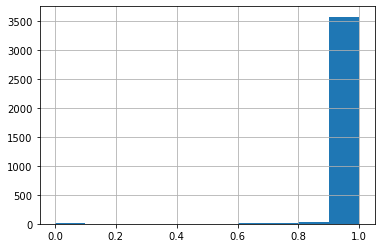

In [22]:
airbnb['host_response_rate'].hist()

In [23]:
# Impute missing values with mode value
mode_val = airbnb['host_response_rate'].mode().iloc[0]
airbnb['host_response_rate'] = airbnb['host_response_rate'].fillna(value = mode_val)

count    3729.000000
mean        0.956028
std         0.110878
min         0.000000
25%         0.970000
50%         0.990000
75%         1.000000
max         1.000000
Name: host_acceptance_rate, dtype: float64

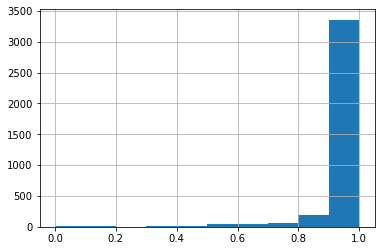

In [24]:
airbnb['host_acceptance_rate'].hist()
airbnb['host_acceptance_rate'].describe()

In [25]:
# Impute missing values with median value 
median_val = airbnb['host_acceptance_rate'].median()
airbnb['host_acceptance_rate'] = airbnb['host_acceptance_rate'].fillna(value = median_val)

In [26]:
# Encode binary variables into categorical type
airbnb['host_is_superhost'] = (airbnb['host_is_superhost'] == 't').astype(int)
airbnb['host_has_profile_pic'] = (airbnb['host_has_profile_pic'] == 't').astype(int)
airbnb['host_identity_verified'] = (airbnb['host_identity_verified'] == 't').astype(int)
airbnb['instant_bookable'] = (airbnb['instant_bookable'] == 't').astype(int)
airbnb['has_availability'] = (airbnb['has_availability'] == 't').astype(int)

In [27]:
# Impute missing values for categorical host_is_superhost
airbnb['host_is_superhost'] = airbnb['host_is_superhost'].fillna(
    airbnb['host_is_superhost'].mode())

In [28]:
# Impute missing values for categorical has_availability
airbnb['has_availability'] = airbnb['has_availability'].fillna(
    airbnb['has_availability'].mode())

In [29]:
# Check for class imbalance

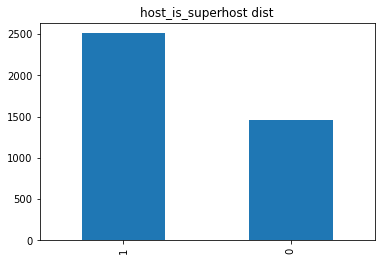

In [30]:
airbnb['host_is_superhost'].value_counts().plot(kind='bar')
plt.title('host_is_superhost dist')
plt.show()

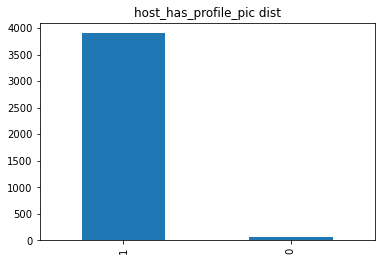

In [31]:
airbnb['host_has_profile_pic'].value_counts().plot(kind='bar')
plt.title('host_has_profile_pic dist')
plt.show()

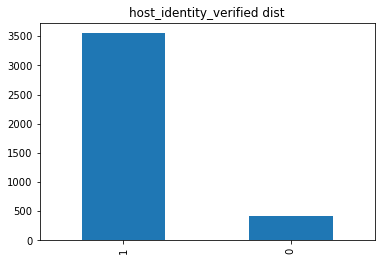

In [32]:
airbnb['host_identity_verified'].value_counts().plot(kind='bar')
plt.title('host_identity_verified dist')
plt.show()

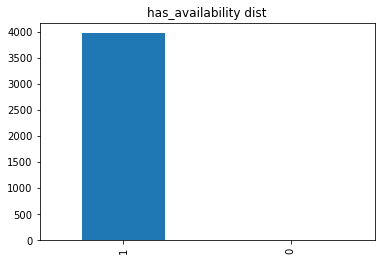

In [33]:
airbnb['has_availability'].value_counts().plot(kind='bar')
plt.title('has_availability dist')
plt.show()

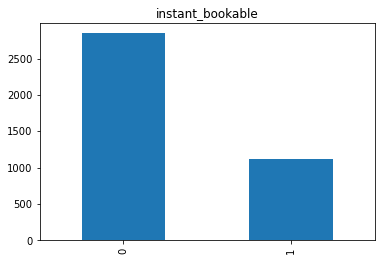

In [34]:
airbnb['instant_bookable'].value_counts().plot(kind='bar')
plt.title('instant_bookable')
plt.show()

In [35]:
airbnb['host_response_time'].value_counts()

within an hour        3365
within a few hours     214
within a day            54
a few days or more      14
Name: host_response_time, dtype: int64

In [36]:
# Re-map neighborhood groups to encode
# 0 = within an hour : rapid , 
# 1 = ['within a few hours', 'within a day'] : within day
# 2 = 'a few days or more' : slow
mapping = {
    'within an hour': 0,
    'within a few hours': 1, 'within a day': 1,
    'a few days or more': 2}

airbnb['host_response_speed'] = airbnb['host_response_time'].map(mapping)

# kNN Imputation on the encoded column
imputer = KNNImputer(n_neighbors=5)

airbnb[['host_response_speed']] = imputer.fit_transform(
    airbnb[['host_response_speed']])

airbnb['host_response_speed'] = airbnb['host_response_speed'].astype(int)


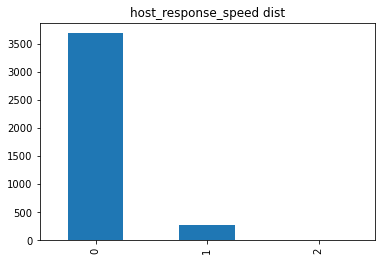

In [37]:
airbnb['host_response_speed'].value_counts().plot(kind='bar')
plt.title('host_response_speed dist')
plt.show()

In [38]:
airbnb['host_response_fast'] =( airbnb['host_response_speed'] == 1).astype(int)

In [39]:
airbnb['host_response_fast'].value_counts()

0    3701
1     268
Name: host_response_fast, dtype: int64

In [40]:
airbnb['last_review'].head()

1    2025-08-31
4    2025-09-16
6    2025-09-21
9    2024-01-01
11   2025-09-07
Name: last_review, dtype: datetime64[ns]

In [41]:
airbnb['recent_reviewed'] = (airbnb['last_review'].dt.year >= 2025).astype(int)
airbnb['recent_reviewed'].value_counts()

1    3764
0     205
Name: recent_reviewed, dtype: int64

In [42]:
airbnb['neighbourhood_group_cleansed'].unique()

array(['Other neighborhoods', 'Ballard', 'Rainier Valley', 'Magnolia',
       'West Seattle', 'Queen Anne', 'Downtown', 'Beacon Hill',
       'Central Area', 'Delridge', 'Northgate', 'Capitol Hill',
       'Seward Park', 'Cascade', 'University District', 'Lake City',
       'Interbay'], dtype=object)

In [43]:
# Re-map neighborhood groups
# 0 = downtown_seattle, 1 = north_seattle, 2 = sw_others
mapping = {
    'Downtown': 0, 'Cascade': 0, 'Capitol Hill': 0, 'Queen Anne': 0,
    'Ballard': 1, 'Interbay': 1, 'Lake City': 1, 'Magnolia': 1, 'Northgate': 1, 'University District': 1}

# Apply mapping and default the rest to 2
airbnb['grp_idx'] = airbnb['neighbourhood_group_cleansed'].map(mapping).fillna(2).astype(int)

# Create dummies
dummies = pd.get_dummies(airbnb['grp_idx'], prefix='grp')
airbnb['north_seattle'] = dummies['grp_1']
airbnb['sw_other'] = dummies['grp_2']

print(airbnb[['neighbourhood_group_cleansed', 'north_seattle', 'sw_other']].head())

   neighbourhood_group_cleansed  north_seattle  sw_other
1           Other neighborhoods              0         1
4                       Ballard              1         0
6           Other neighborhoods              0         1
9                Rainier Valley              0         1
11                     Magnolia              1         0


In [44]:
import ast

featured_amenities = ['Microwave','Kitchen', 'Stove','Refrigerator','Barbecue', 'Outdoor dining', 
                      'Free street parking','Workspace',
                     'Hot tub', 'Heating','Air conditioning', 
                     'Wifi', 'TV','cameras',
                     'Washer', 'Dryer', 
                     'Self check-in', 'Host greets']
def create_amenity_dummies(df, col, amenities):
    for keyword in amenities:
        # clean column name
        new_col = (
            keyword.replace(" ", "_")
                   .replace("-", "_")
                   .lower() )
        
        # create dummy using case-insensitive substring matching
        df[new_col] = df[col].apply(
            lambda lst: 1 if any(
                keyword.lower() in item.lower()
                for item in (ast.literal_eval(lst) if isinstance(lst, str) else (lst if isinstance(lst, list) else []))
            ) else 0)
    return df

create_amenity_dummies(airbnb, 'amenities', featured_amenities)

,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,...,hot_tub,heating,air_conditioning,wifi,tv,cameras,washer,dryer,self_check_in,host_greets
1,9.419000e+03,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",30559,2009-08-09,"Seattle, WA",within an hour,1.0,0.97,...,0,1,0,1,0,1,0,1,0,1
4,2.500200e+04,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,102684,2010-04-02,"Seattle, WA",within an hour,1.0,1.00,...,0,1,1,1,1,0,1,1,1,0
6,1.191030e+05,Teeny Tiny Guestyhouse!,It's a Teeny Tiny Guesthouse! Enter the words...,Fremont is about a 10 minute bus ride from dow...,601600,2011-05-18,"Seattle, WA",within a few hours,1.0,1.00,...,0,1,0,1,0,0,0,1,0,1
9,2.158820e+05,Relaxing Garden Cottage w/ Parking!,Relax and enjoy the privacy of your own Seattl...,NaN,971336,2011-08-15,"Seattle, WA",within an hour,1.0,1.00,...,0,1,0,1,1,0,0,1,1,0
11,2.265360e+05,Serene Room in Sunny Cottage near Discovery Park,This is a spacious room in a 1920's cottage h...,It does not feel as if you are in a big city.<...,209571,2010-08-22,"Seattle, WA",within an hour,1.0,0.91,...,0,1,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6907,1.500000e+18,Forest Hideaway: Private Suite by Lincoln Park,"Escape to a dreamy hideaway, where your privat...",West Seattle is one of the city’s most charmin...,31551373,2015-04-19,"Seattle, WA",within an hour,1.0,1.00,...,0,1,0,1,1,1,1,1,1,0
6910,1.500000e+18,Modern Tri-Level 3bTH/Private Parking/Backyard/UW,Spacious and family-friendly townhome just min...,NaN,716080659,2025-08-28,NaN,within an hour,1.0,1.00,...,0,1,1,1,1,1,1,1,1,0
6930,1.510000e+18,"Stylish Home Near Stadiums, Downtown, Mt View ...","Welcome to our sleek 2024 townhome, perfectly ...","Nestled just southeast of downtown, Beacon Hil...",53859262,2016-01-08,"Seattle, WA",within an hour,1.0,0.99,...,0,1,1,1,1,1,1,1,1,0
6938,1.510000e+18,Bright & Modern Wallingford Loft,Experience this modern loft in the vibrant Wal...,NaN,258634994,2019-04-28,"Seattle, WA",within an hour,1.0,1.00,...,0,1,1,1,1,0,0,0,1,0


In [45]:
airbnb['price'].describe()

count    3969.000000
mean      180.850189
std       199.062822
min        15.000000
25%       110.000000
50%       152.000000
75%       211.000000
max      9400.000000
Name: price, dtype: float64

In [46]:
# Get columns index
for i, col in enumerate(airbnb.columns):
    print(i, col)

0 id
1 name
2 description
3 neighborhood_overview
4 host_id
5 host_since
6 host_location
7 host_response_time
8 host_response_rate
9 host_acceptance_rate
10 host_is_superhost
11 host_has_profile_pic
12 host_identity_verified
13 neighbourhood_cleansed
14 neighbourhood_group_cleansed
15 latitude
16 longitude
17 room_type
18 property_type
19 accommodates
20 bathrooms
21 bathrooms_text
22 bedrooms
23 beds
24 amenities
25 price
26 minimum_nights
27 maximum_nights
28 minimum_minimum_nights
29 maximum_minimum_nights
30 minimum_maximum_nights
31 maximum_maximum_nights
32 minimum_nights_avg_ntm
33 maximum_nights_avg_ntm
34 calendar_updated
35 has_availability
36 availability_30
37 availability_60
38 availability_90
39 availability_365
40 number_of_reviews
41 number_of_reviews_ltm
42 number_of_reviews_l30d
43 availability_eoy
44 number_of_reviews_ly
45 estimated_occupancy_l365d
46 estimated_revenue_l365d
47 first_review
48 last_review
49 review_scores_rating
50 review_scores_accuracy
51 review_s

In [47]:
# Create a subset of original data for model development
cols = (
    list(range(8, 11)) + [17]+ [19,20, 22, 23] + list(range(25, 28)) +  list(range(36, 38)) +  
    [40,45] +  list(range(47, 83)))

data = airbnb.iloc[:, cols]
data.isna().sum()

host_response_rate             0
host_acceptance_rate           0
host_is_superhost              0
room_type                      0
accommodates                   0
bathrooms                      0
bedrooms                       0
beds                           0
price                          0
minimum_nights                 0
maximum_nights                 0
availability_30                0
availability_60                0
number_of_reviews              0
estimated_occupancy_l365d      0
first_review                   0
last_review                    0
review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
instant_bookable               0
reviews_per_month              0
host_lifetime                  0
host_response_speed            0
host_response_fast             0
recent_reviewed                0
grp_idx   

In [48]:
# EDA

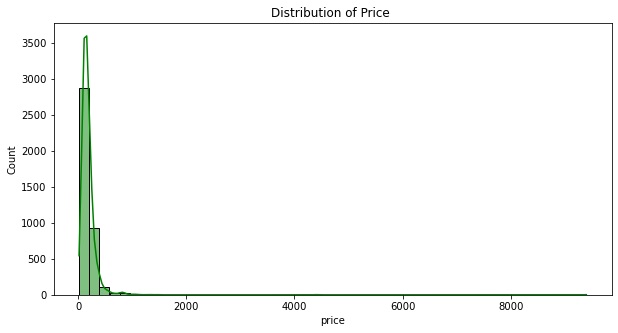

In [49]:
plt.figure(figsize=(10,5))
sns.histplot(data['price'], bins=50, kde=True, color='green')
plt.title('Distribution of Price ')
plt.show()

In [50]:
data['price'].describe()

count    3969.000000
mean      180.850189
std       199.062822
min        15.000000
25%       110.000000
50%       152.000000
75%       211.000000
max      9400.000000
Name: price, dtype: float64


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


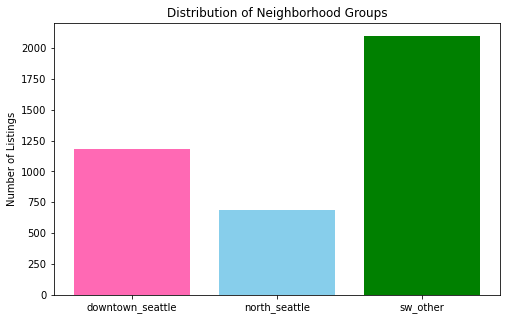

In [51]:
# Visualize the distribution of the three neighborhood groups
data['downtown_seattle'] = 1 - data['north_seattle'] - data['sw_other']

group_counts = {
    'downtown_seattle': data['downtown_seattle'].sum(),
    'north_seattle': data['north_seattle'].sum(),
    'sw_other': data['sw_other'].sum()}

plt.figure(figsize=(8,5))
plt.bar(group_counts.keys(), group_counts.values(), color=['hotpink', 'skyblue', 'green'])
plt.ylabel('Number of Listings')
plt.title('Distribution of Neighborhood Groups')
plt.show()

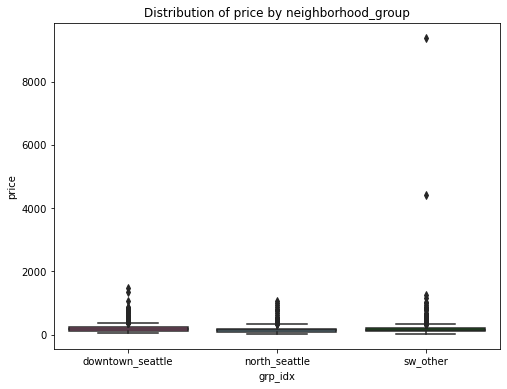

In [52]:
# Plot distribution of price across neighborhood group
plt.figure(figsize=(8,6))
sns.boxplot(x='grp_idx', y='price', data=data, palette=['hotpink', 'skyblue', 'green'])

plt.xticks([0,1,2], ['downtown_seattle', 'north_seattle', 'sw_other'])
plt.ylabel('price')
plt.title('Distribution of price by neighborhood_group')
plt.show()

In [53]:
# Extreme price outliers are from listings from Southwest Seatte or other areas that are not
# in Downtown and North Seattle 

In [54]:
# Compute 99th percentile
price_99 = data['price'].quantile(0.99)

# Filter the top 10% of prices - higher tiers
outliers = data[data['price'] > price_99]

In [55]:
outliers['price'].describe()

count      40.000000
mean     1199.500000
std      1450.016021
min       733.000000
25%       798.750000
50%       844.000000
75%      1002.500000
max      9400.000000
Name: price, dtype: float64

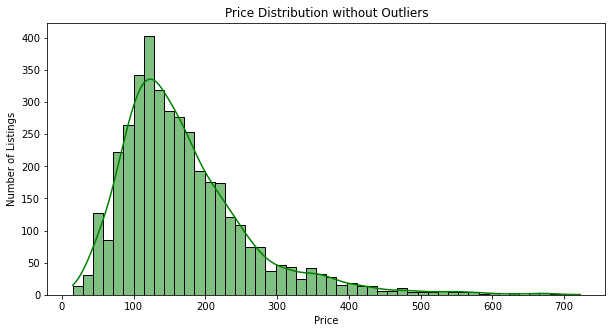

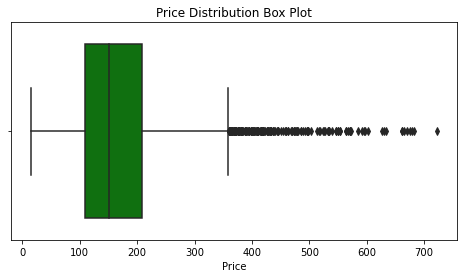

In [56]:
#Remove extreme outliers for better histogram visualization
price_filtered = data['price'][data['price'] < data['price'].quantile(0.99)]

# Histogram without outliers
plt.figure(figsize=(10,5))
sns.histplot(price_filtered, bins=50, kde=True, color='green')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.title('Price Distribution without Outliers')
plt.show()

# Boxplot 
plt.figure(figsize=(8,4))
sns.boxplot(x=price_filtered, color='green')
plt.xlabel('Price')
plt.title('Price Distribution Box Plot')
plt.show()

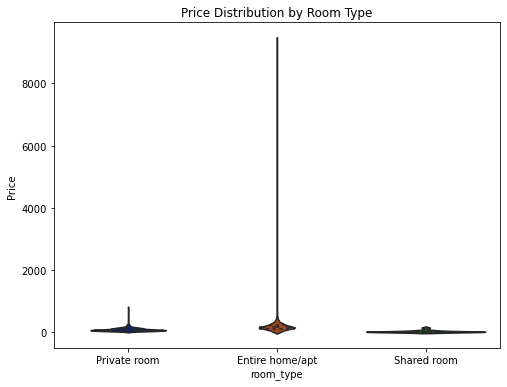

In [57]:
# Overall price distribution by room type

plt.figure(figsize=(8,6))
sns.violinplot(x='room_type', y='price', data=data, palette='dark', inner='quartile')
plt.ylabel('Price')
plt.title('Price Distribution by Room Type')
plt.show()

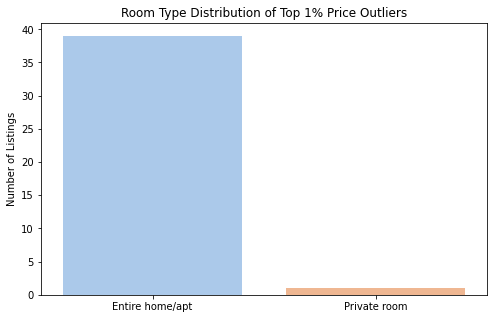

In [58]:
# Room type distribution of the outliers
room_counts = outliers['room_type'].value_counts()

# Plot bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel')
plt.ylabel('Number of Listings')
plt.title('Room Type Distribution of Top 1% Price Outliers')
plt.show()

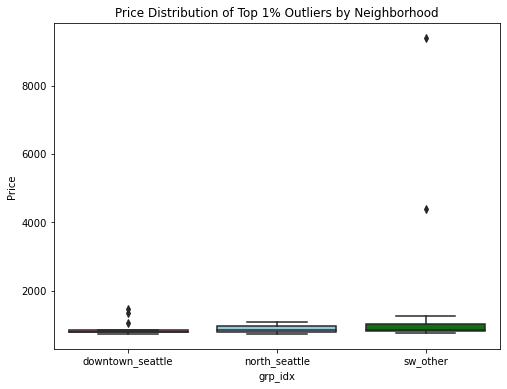

In [59]:
# Identify the neighborhood group with outliers
plt.figure(figsize=(8,6))
sns.boxplot(x='grp_idx', y='price', data=outliers, palette=['hotpink', 'skyblue', 'green']) 
plt.xticks([0,1,2], ['downtown_seattle', 'north_seattle', 'sw_other'])
plt.ylabel('Price')
plt.title('Price Distribution of Top 1% Outliers by Neighborhood')
plt.show()

In [60]:
## Extreme price outliers are Entire home/aptm and Private room in Southwest and other areas 

In [61]:
# Remove luxury, high-end listings in the top 1% price

data = data[data['price'] <= price_99].reset_index(drop=True)

In [62]:
data['price'].describe()

count    3929.000000
mean      170.479613
std        92.085240
min        15.000000
25%       109.000000
50%       151.000000
75%       209.000000
max       722.000000
Name: price, dtype: float64

In [63]:
# Create binary variable from room_type
data['entire_place'] = (data['room_type'] == 'Entire home/apt').astype(int)

In [64]:
# Keep only obs where listing is private types
data = data[data['entire_place'] == 1]

In [65]:
data['price'].describe()

count    3255.000000
mean      186.258556
std        90.962005
min        49.000000
25%       123.000000
50%       164.000000
75%       222.000000
max       722.000000
Name: price, dtype: float64

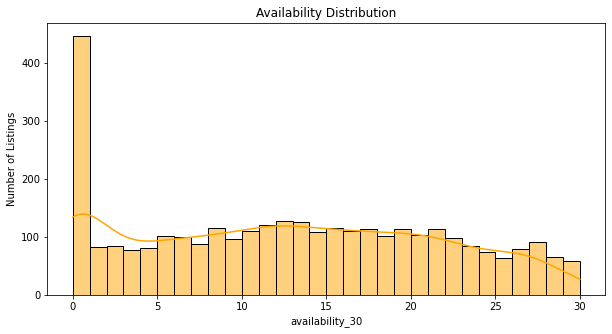

In [66]:
# Availability within 30 days distribution

plt.figure(figsize=(10,5))
sns.histplot(data['availability_30'], bins=30, kde=True, color='orange')
plt.xlabel('availability_30')
plt.ylabel('Number of Listings')
plt.title('Availability Distribution')
plt.show()


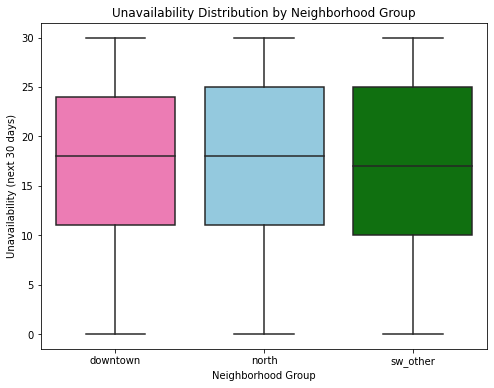

In [67]:
data['unavail_30'] = 30 - data['availability_30']
# Availability of 90 days in the future across neighborhood groups
plt.figure(figsize=(8,6))
sns.boxplot(
    x='grp_idx',
    y='unavail_30',
    data=data,
    palette=['hotpink', 'skyblue', 'green'],
    order=[0,1,2])

plt.xticks([0,1,2], ['downtown', 'north', 'sw_other'])
plt.ylabel('Unavailability (next 30 days)')
plt.xlabel('Neighborhood Group')
plt.title('Unavailability Distribution by Neighborhood Group')
plt.show()

In [68]:
data[["microwave","kitchen","stove","refrigerator","barbecue","outdoor_dining",
      "free_street_parking","workspace","hot_tub",
      "heating","air_conditioning","wifi","tv","cameras",
      "washer","dryer","self_check_in","host_greets"]].apply(pd.Series.value_counts)

,microwave,kitchen,stove,refrigerator,barbecue,outdoor_dining,free_street_parking,workspace,hot_tub,heating,air_conditioning,wifi,tv,cameras,washer,dryer,self_check_in,host_greets
0,221,133,594,297,2638,2008,989,967,2964,103,1584,7,160,1592,379,67,422,3162
1,3034,3122,2661,2958,617,1247,2266,2288,291,3152,1671,3248,3095,1663,2876,3188,2833,93


In [69]:
data.isna().sum()

host_response_rate             0
host_acceptance_rate           0
host_is_superhost              0
room_type                      0
accommodates                   0
bathrooms                      0
bedrooms                       0
beds                           0
price                          0
minimum_nights                 0
maximum_nights                 0
availability_30                0
availability_60                0
number_of_reviews              0
estimated_occupancy_l365d      0
first_review                   0
last_review                    0
review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
instant_bookable               0
reviews_per_month              0
host_lifetime                  0
host_response_speed            0
host_response_fast             0
recent_reviewed                0
grp_idx   

In [70]:
# MODELLING #

In [71]:
X = data[['host_acceptance_rate', 'host_is_superhost', 
           'bathrooms','bedrooms',  'accommodates','availability_30',
          'review_scores_rating','review_scores_cleanliness', 'estimated_occupancy_l365d',
          'north_seattle', 'sw_other', 'recent_reviewed',
          'stove', 'free_street_parking','workspace', 'hot_tub', 'wifi', 'tv', 'washer',]]
X = sm.add_constant(X)

y = np.log1p(data['price'])

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=108)

In [73]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error)

# Fit the OLS model
linear = sm.OLS(y_train, X_train).fit()
print(linear.summary())

# Predictions
y_pred   = linear.predict(X_test)  # log scale
y_pred_org = np.expm1(y_pred) # orginal scale  
actual     = np.expm1(y_test) # original scale

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     180.6
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:03:14   Log-Likelihood:                -248.45
No. Observations:                2278   AIC:                             536.9
Df Residuals:                    2258   BIC:                             651.5
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [74]:

# Metrics on log scale
print("\n── Metrics on Log Scale")
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae:.4f}")

# Metrics on original scale
print("\n── Metrics on Original Scale")
mse_org = mean_squared_error(actual, y_pred_org)
rmse_org = np.sqrt(mse_org)
mae_org = mean_absolute_error(actual, y_pred_org)
mape_org = mean_absolute_percentage_error(actual, y_pred_org)
print(f"MSE : {mse_org:.4f}")
print(f"RMSE : {rmse_org:.4f}")
print(f"MAE : {mae_org:.4f}")
print(f"MAPE : {mape_org:.4f}")
print(f"\nMedian price :", data['price'].median())


── Metrics on Log Scale
MSE : 0.0704
RMSE : 0.2653
MAE : 0.2045

── Metrics on Original Scale
MSE : 3442.1406
RMSE : 58.6698
MAE : 39.4664
MAPE : 0.2042

Median price : 164.0


In [75]:
# Calculate SS_res and SS_tot on original scale
ss_res = np.sum((actual - y_pred_org)**2)
ss_tot = np.sum((actual - np.mean(actual))**2)

# Calculate R-squared
r2_org = 1 - (ss_res / ss_tot)

print(f"R-squared (Original Scale): {r2_org:.4f}")

R-squared (Original Scale): 0.5683


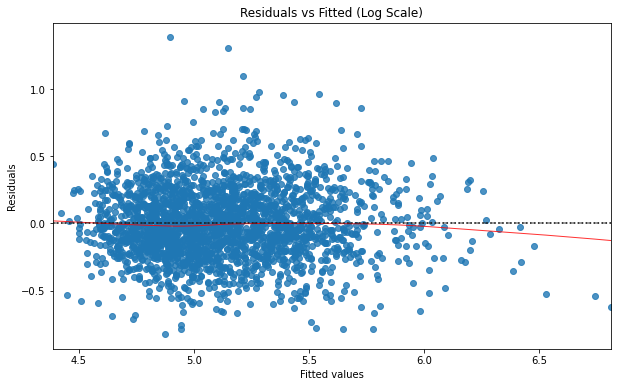

In [76]:
# Create residual plot on log scale
fitted_values = linear.fittedvalues
residuals = linear.resid

plt.figure(figsize=(10, 6))
sns.residplot(x=fitted_values, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Residuals vs Fitted (Log Scale)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

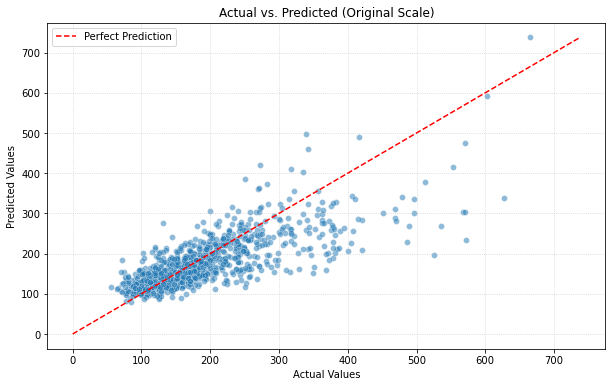

In [77]:
# Create scatter plot of prediction vs actual on original scale
plt.figure(figsize=(10, 6))

sns.scatterplot(x=actual, y=y_pred_org, alpha=0.5)
max_val = max(actual.max(), y_pred_org.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted (Original Scale)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [78]:
X = data[['host_acceptance_rate', 'host_is_superhost', 
           'bathrooms','bedrooms',  'accommodates','availability_30',
          'review_scores_rating','review_scores_cleanliness', 'estimated_occupancy_l365d',
          'north_seattle', 'sw_other', 'recent_reviewed',
          'stove', 'free_street_parking','workspace', 'hot_tub', 'wifi', 'tv', 'washer',]]
X = sm.add_constant(X)
y = np.log1p(data['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=108)

linear = sm.OLS(y_train, X_train).fit(cov_type='HC3')  # <-- only change
print(linear.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     175.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:03:15   Log-Likelihood:                -248.45
No. Observations:                2278   AIC:                             536.9
Df Residuals:                    2258   BIC:                             651.5
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [79]:
# Random Forest 

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error)
import shap

In [81]:
X = data[['host_acceptance_rate', 'host_is_superhost', 
           'bathrooms','bedrooms',  'accommodates','availability_30',
          'review_scores_rating','review_scores_cleanliness', 'estimated_occupancy_l365d',
          'north_seattle', 'sw_other', 'recent_reviewed',
          'stove', 'free_street_parking','workspace', 'hot_tub', 'wifi', 'tv', 'washer',]]
y = np.log1p(data['price'])

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=108)

rf = RandomForestRegressor(
    n_estimators=100,   
    max_depth=15,  
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1)

#Train model
rf.fit(X_train, y_train)

#Prediction
y_rf = rf.predict(X_test)


# Reverse log transform for original scale metrics
y_rf_org = np.expm1(y_rf)
actual_org = np.expm1(y_test)


In [83]:

# Metrics on log scale
print("\n── Random Forest: Metrics on Log Scale")
r2_log   = r2_score(y_test, y_rf)
mse_log  = mean_squared_error(y_test, y_rf)
rmse_log = np.sqrt(mse_log)
mae_log  = mean_absolute_error(y_test, y_rf)
mape_log = mean_absolute_percentage_error(y_test, y_rf)

print(f"R²   : {r2_log:.4f}")
print(f"MSE  : {mse_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"MAE  : {mae_log:.4f}")
print(f"MAPE : {mape_log:.4f}")

# Metrics on original scale
print("\n── Random Forest: Metrics on Original Scale")
r2_org   = r2_score(actual_org, y_rf_org)
mse_org  = mean_squared_error(actual_org, y_rf_org)
rmse_org = np.sqrt(mse_org)
mae_org  = mean_absolute_error(actual_org, y_rf_org)
mape_org = mean_absolute_percentage_error(actual_org, y_rf_org)


print(f"R²   : {r2_org:.4f}")
print(f"MSE  : {mse_org:.4f}")
print(f"RMSE : {rmse_org:.4f}")
print(f"MAE  : {mae_org:.4f}")
print(f"MAPE : {mape_org:.4f}")

print(f"\nMedian price: {data['price'].median()}")


── Random Forest: Metrics on Log Scale
R²   : 0.5914
MSE  : 0.0718
RMSE : 0.2680
MAE  : 0.2070
MAPE : 0.0401

── Random Forest: Metrics on Original Scale
R²   : 0.5487
MSE  : 3598.2163
RMSE : 59.9851
MAE  : 40.2359
MAPE : 0.2084

Median price: 164.0


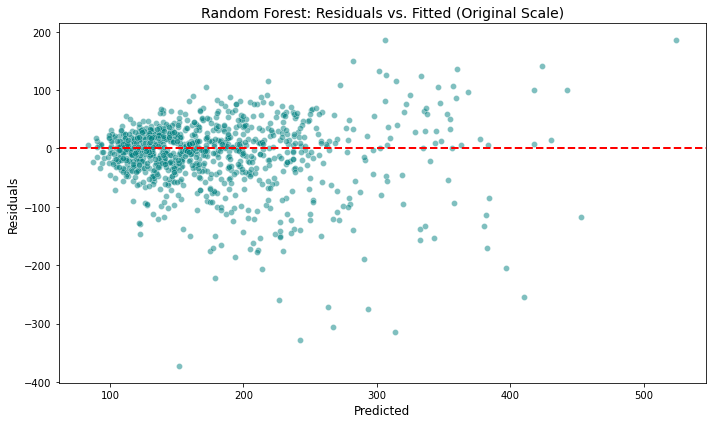

In [84]:
residuals_original = y_rf_org - actual_org
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_rf_org, y=residuals_original, alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Random Forest: Residuals vs. Fitted (Original Scale)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.tight_layout()
plt.show()

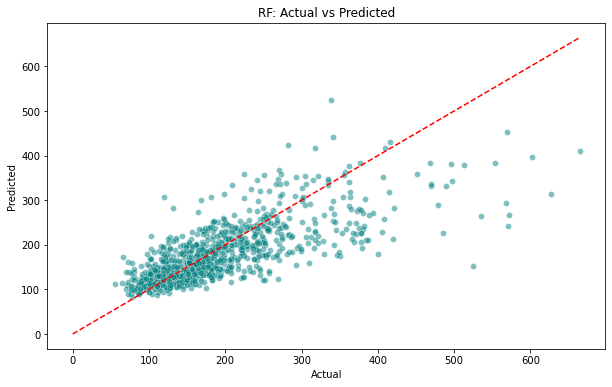

In [85]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=actual_org, y=y_rf_org, alpha=0.5, color='teal')
max_val = max(actual_org.max(), y_rf_org.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RF: Actual vs Predicted')
plt.show()

In [86]:
# RF also suffers from heteroscedasticity while RMSE doesn't improve

In [87]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=108,
    n_jobs=-1)

# Fit the model
xgb.fit(X_train, y_train)

# Predict on log scale
y_xgb = xgb.predict(X_test)


# Reverse log transform for original scale metrics
y_xgb_org = np.expm1(y_xgb)
actual_org = np.expm1(y_test)


In [88]:

# Metrics on log scale
print("\n── XGBoost: Metrics on Log Scale")
r2_log   = r2_score(y_test, y_xgb)
mse_log  = mean_squared_error(y_test, y_xgb)
rmse_log = np.sqrt(mse_log)
mae_log  = mean_absolute_error(y_test, y_xgb)
mape_log = mean_absolute_percentage_error(y_test, y_xgb)

print(f"R²   : {r2_log:.4f}")
print(f"MSE  : {mse_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"MAE  : {mae_log:.4f}")
print(f"MAPE : {mape_log:.4f}")

# Metrics on original scale
print("\n── XGBoost: Metrics on Original Scale")
r2_org   = r2_score(actual_org, y_xgb_org)
mse_org  = mean_squared_error(actual_org, y_xgb_org)
rmse_org = np.sqrt(mse_org)
mae_org  = mean_absolute_error(actual_org, y_xgb_org)
mape_org = mean_absolute_percentage_error(actual_org, y_xgb_org)


print(f"R²   : {r2_org:.4f}")
print(f"MSE  : {mse_org:.4f}")
print(f"RMSE : {rmse_org:.4f}")
print(f"MAE  : {mae_org:.4f}")
print(f"MAPE : {mape_org:.4f}")

print(f"\nMedian price: {data['price'].median()}")


── XGBoost: Metrics on Log Scale
R²   : 0.6101
MSE  : 0.0685
RMSE : 0.2618
MAE  : 0.2030
MAPE : 0.0393

── XGBoost: Metrics on Original Scale
R²   : 0.5677
MSE  : 3446.4203
RMSE : 58.7062
MAE  : 39.3804
MAPE : 0.2029

Median price: 164.0


In [89]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [90]:
# SVR Pipeline 
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='linear', C=10, epsilon=0.3, gamma='scale'))])

# Fit
svr_pipeline.fit(X_train, y_train)

# Predict
y_svr  = svr_pipeline.predict(X_test)


In [91]:
# Metrics on log scale
print("\n── Metrics on Log Scale")
mse_org = mean_squared_error(y_test, y_svr)
rmse_org = np.sqrt(mse_org)
mae_org = mean_absolute_error(y_test, y_svr)
mape_org = mean_absolute_percentage_error(y_test, y_svr)

print(f"MSE : {mse_org:.4f}")
print(f"RMSE : {rmse_org:.4f}")
print(f"MAE : {mae_org:.4f}")
print(f"MAPE : {mape_org:.4f}")
print(f"\nMedian price :", data['price'].median())

# Reverse log transform for original scale metrics
y_svr_org = np.expm1(y_svr)
actual_org = np.expm1(y_test)


# Metrics on original scale
print("\n── SVR: Metrics on Original Scale")
r2_org   = r2_score(actual_org, y_svr_org)
mse_org  = mean_squared_error(actual_org, y_svr_org)
rmse_org = np.sqrt(mse_org)
mae_org  = mean_absolute_error(actual_org, y_svr_org)
mape_org = mean_absolute_percentage_error(actual_org, y_svr_org)


print(f"R²   : {r2_org:.4f}")
print(f"MSE  : {mse_org:.4f}")
print(f"RMSE : {rmse_org:.4f}")
print(f"MAE  : {mae_org:.4f}")
print(f"MAPE : {mape_org:.4f}")




── Metrics on Log Scale
MSE : 0.0702
RMSE : 0.2649
MAE : 0.2049
MAPE : 0.0397

Median price : 164.0

── SVR: Metrics on Original Scale
R²   : 0.5701
MSE  : 3427.4461
RMSE : 58.5444
MAE  : 39.6549
MAPE : 0.2062


In [92]:
def svr_predict(X):
    return svr_pipeline.predict(X)

# Create SHAP explainer
explainer = shap.Explainer(svr_predict, X_train)

# Compute SHAP values for the test set
shap_values = explainer(X_test)

PermutationExplainer explainer: 978it [09:38,  1.67it/s]                                                               


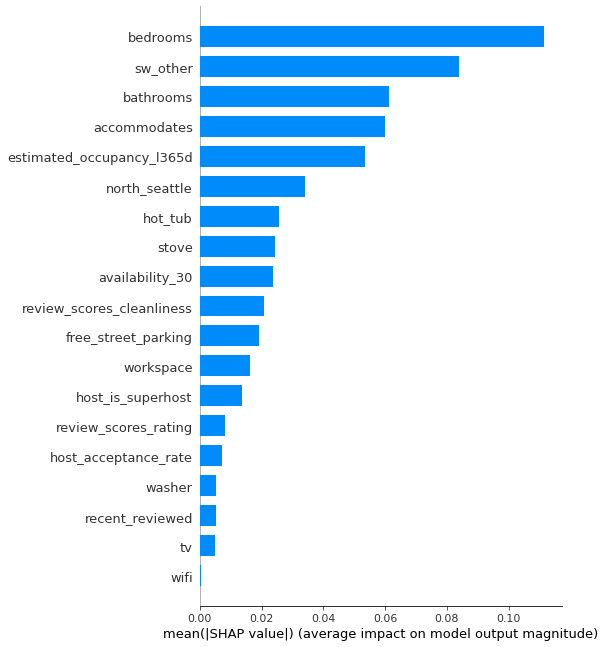

In [93]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [94]:
# Post estimation correction OLS

In [95]:
X = data[['host_acceptance_rate', 'host_is_superhost', 
           'bathrooms','bedrooms',  'accommodates','availability_30',
          'review_scores_rating','review_scores_cleanliness', 'estimated_occupancy_l365d',
          'north_seattle', 'sw_other', 'recent_reviewed',
          'stove', 'free_street_parking','workspace', 'hot_tub', 'wifi', 'tv', 'washer',]]
X = sm.add_constant(X)
y = np.log1p(data['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=108)

linear = sm.OLS(y_train, X_train).fit(cov_type='HC3') 
print(linear.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     175.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:12:58   Log-Likelihood:                -248.45
No. Observations:                2278   AIC:                             536.9
Df Residuals:                    2258   BIC:                             651.5
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

PermutationExplainer explainer: 978it [00:21, 26.05it/s]                                                               


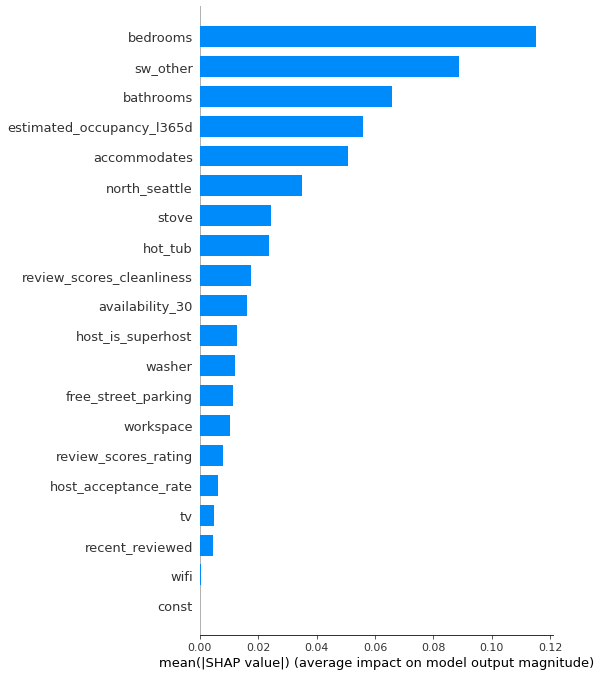

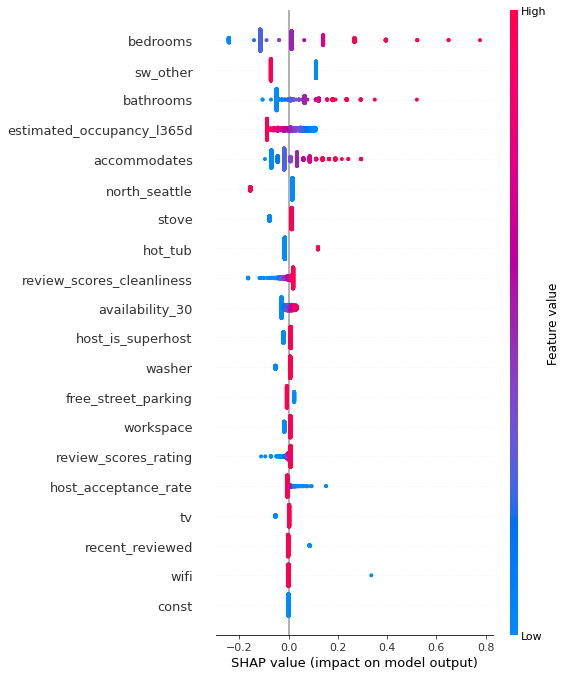

In [96]:
import shap

def model_predict(X):
    return linear.predict(X)

# Create SHAP explainer
explainer = shap.Explainer(model_predict, X_train)

# Compute SHAP values for test set
shap_values = explainer(X_test)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Beeswarm plot
shap.summary_plot(shap_values, X_test)
